In [1]:
%matplotlib inline 

import numpy as np 
import matplotlib.pyplot as plt

import matplotlib as mpl
from cycler import cycler
colors = ['#0173b2','#de8f05','#029e73','#d55e00','#cc78bc','#ca9161','#fbafe4','#949494','#ece133','#56b4e9']
mpl.rcParams['axes.prop_cycle'] = cycler(color=colors)


import pandas as pd

import os

from matplotlib.lines import Line2D
import git_segregation as seg

%matplotlib inline
plt.rcParams['figure.dpi'] = 300  # Increase DPI (default is usually 100)

In [2]:
#Historical Data file names
data_names = ['nhgis0013_ds120_1990_blck_grp.csv', 'nhgis0013_ds147_2000_blck_grp.csv', 'nhgis0013_ds172_2010_blck_grp.csv', 'nhgis0013_ds248_2020_blck_grp.csv']

In [ ]:
#Import Historical Data
data_vec0 = []
for file_name in data_names:
    file_path = os.path.join("Census Data", file_name) #Or the folder in which the nhgis0013_ds120_1990_blck_grp and similar are saved
    if file_path:
        print(f"Loading file: {file_path}")
        data_vec0.append(pd.read_csv(file_path, encoding='latin1', low_memory=False))
    else:
        print(f"File not found: {file_name}")

Loading file: Census Data\nhgis0013_ds120_1990_blck_grp.csv
Loading file: Census Data\nhgis0013_ds147_2000_blck_grp.csv
Loading file: Census Data\nhgis0013_ds172_2010_blck_grp.csv
Loading file: Census Data\nhgis0013_ds248_2020_blck_grp.csv


In [4]:
#Obtains the variable name
def get_var_name(var):
    for name, value in globals().items():
        if value is var:
            return name

In [5]:
#Data for 1990
blockgroup = 'GISJOIN',
statea = 'STATEA',
countya = 'COUNTYA',
total = ['ET2001', 'ET2002', 'ET2003', 'ET2004', 'ET2005',
'ET2006', 'ET2007', 'ET2008', 'ET2009', 'ET2010']
white = 'ET2001',
black = 'ET2002',
native = 'ET2003',
asian = 'ET2004',
hispanic = ['ET2006', 'ET2007', 'ET2008', 'ET2009', 'ET2010']
institutional = ['EUM001', 'EUM002', 'EUM003', 'EUM004', 'EUM005']
vec_names = [blockgroup, statea, countya, total, white, black, native, asian, hispanic, institutional]

d1990 = pd.DataFrame()
for name in vec_names:
    if len(name) == 1:
        d1990[get_var_name(name)] = data_vec0[0][name[0]]
    else:
        d1990[get_var_name(name)] = np.sum(data_vec0[0][name], 1)

d1990['other'] = d1990['total'] - d1990['white'] - d1990['black'] - d1990['native'] - d1990['asian'] - d1990['hispanic']
d1990['year'] = 1990

In [6]:
#Data for 2000
blockgroup = 'GISJOIN',
statea = 'STATEA',
countya = 'COUNTYA',
total = ['FYF001', 'FYF002', 'FYF003', 'FYF004', 'FYF005',
    'FYF006', 'FYF007', 'FYF008', 'FYF009', 'FYF010', 'FYF011', 'FYF012', 'FYF013', 'FYF014']
white = 'FYF001',
black = 'FYF002',
native = 'FYF003',
asian = ['FYF004', 'FYF005']
hispanic = ['FYF008', 'FYF009', 'FYF010', 'FYF011', 'FYF012', 'FYF013', 'FYF014']
institutional = ['F4I001', 'F4I002', 'F4I003']
vec_names = [blockgroup, statea, countya, total, white, black, native, asian, hispanic, institutional]

d2000 = pd.DataFrame()
for name in vec_names:
    if len(name) == 1:
        d2000[get_var_name(name)] = data_vec0[1][name[0]]
    else:
        d2000[get_var_name(name)] = np.sum(data_vec0[1][name], 1)

d2000['other'] = d2000['total'] - d2000['white'] - d2000['black'] - d2000['native'] - d2000['asian'] - d2000['hispanic']
d2000['year'] = 2000

In [7]:
#Data for 2010
blockgroup = 'GISJOIN',
statea = 'STATEA',
countya = 'COUNTYA',
total = 'H7Z001',
white = 'H7Z003',
black = 'H7Z004',
native = 'H7Z005',
asian = ['H7Z006', 'H7Z007']
hispanic = 'H7Z010',
institutional = 'H80002',
vec_names = [blockgroup, statea, countya, total, white, black, native, asian, hispanic, institutional]

d2010 = pd.DataFrame()
for name in vec_names:
    if len(name) == 1:
        d2010[get_var_name(name)] = data_vec0[2][name[0]]
    else:
        d2010[get_var_name(name)] = np.sum(data_vec0[2][name], 1)

d2010['other'] = d2010['total'] - d2010['white'] - d2010['black'] - d2010['native'] - d2010['asian'] - d2010['hispanic']
d2010['year'] = 2010

In [8]:
#Data for 2020
blockgroup = 'GISJOIN',
statea = 'STATEA',
countya = 'COUNTYA',
total = 'U7C001',
white = 'U7C005',
black = 'U7C006',
native = 'U7C007',
asian = ['U7C008', 'U7C009']
hispanic = 'U7C002',
institutional = 'U7F002',
vec_names = [blockgroup, statea, countya, total, white, black, native, asian, hispanic, institutional]

d2020 = pd.DataFrame()
for name in vec_names:
    if len(name) == 1:
        d2020[get_var_name(name)] = data_vec0[3][name[0]]
    else:
        d2020[get_var_name(name)] = np.sum(data_vec0[3][name], 1)

d2020['other'] = d2020['total'] - d2020['white'] - d2020['black'] - d2020['native'] - d2020['asian'] - d2020['hispanic']
d2020['year'] = 2020

In [9]:
#combine 
data = pd.concat([d1990, d2000, d2010, d2020])
data = data[data['statea'] != 72] #excludes Puerto Rico
data['countyfips'] = data['statea'].astype(str).str.zfill(2) +data['countya'].astype(str).str.zfill(3)
data = data.drop(['statea', 'countya'], axis = 1)
data = data.reset_index(drop=True)


In [ ]:
# add CBSA (2020 definitions)

file_name = 'list1_2020.xls'

# Find the file in the search directories
file_path = os.path.join("Census Data", file_name) #use the folder where list1_2020 is saved   

cbsa = pd.read_excel(file_path, header = 2)[:-4] #removes notes at the end of the file
cbsa['countyfips'] = cbsa['FIPS State Code'].astype(int).astype(str).str.zfill(2)+ cbsa['FIPS County Code'].astype(int).astype(str).str.zfill(3)
cbsa = cbsa[['CBSA Title', 'County/County Equivalent', 'countyfips']]
cbsa = cbsa.rename(columns={'CBSA Title': 'cbsatitle', 'County/County Equivalent': 'countyname'})

In [11]:
#Add Miami-Dade County (since it had fips code change)

add_county = pd.DataFrame({'cbsatitle': "Miami-Fort Lauderdale-Pompano Beach, FL", 
'countyname': "Miami-Dade County", 'countyfips': "12025"}, index = [1916])

cbsa = pd.concat([cbsa, add_county])


In [12]:
#merge data
d = pd.merge(data, cbsa, on = 'countyfips')

#Only keep block groups that have a non-zero population
d = d[d['total'] != 0]

#Only keep block groups that are have less than 25% instituationalized populations
d = d[d['institutional']/d['total'] < 0.25]

#Only select cities that had at least 1000 of each each group for all years
which_cities = ((d.groupby(['cbsatitle', 'year'])[['white', 'black', 'asian', 'hispanic']].sum() > 1000).prod(axis = 1) == 1).groupby('cbsatitle').prod().astype(bool)
allowed_cities = list(which_cities[which_cities == True].index)
d = d[d['cbsatitle'].isin(allowed_cities)]

In [13]:
#Obtains a size-sorted list of the cities
largest_cities = np.array(allowed_cities)[np.flip(np.argsort(d.groupby('cbsatitle')['total'].sum().to_numpy()))]

#obtains groupby objects of the data
grouped = d.groupby(['cbsatitle', 'year'])
grouped2 = d.groupby(['year', 'cbsatitle'])

#The decades considered
decades = [1990, 2000, 2010, 2020]

In [14]:
#Returns weighted average and standard deviation of a 1d array, a. 
def weighted_std(a, w):
    avg = np.average(a, weights=w)
    var = np.average((a - avg)**2, weights=w)
    return [avg, np.sqrt(var)]

#Total population of group 1 + group 2 in the city, x = (group1, group2)
def Tot(x):
    try:
        x = x.to_numpy()
    except:
        pass

    t = np.sum(x, 1)

    T = np.sum(t)
    return T

In [15]:
#A general computation of a function for a city. Takes in group1 and group2, the city name, the year, and the function (can be Dis, Dis_Gaus, Dis_info, Avg, Tot, etc.)
def city_func(group1, group2, city, year, func, arg = None):
    if arg == None:
        return func(grouped.get_group((city, year))[[group1, group2]].to_numpy())
    else:
        return func(grouped.get_group((city, year))[[group1, group2]].to_numpy(), arg)

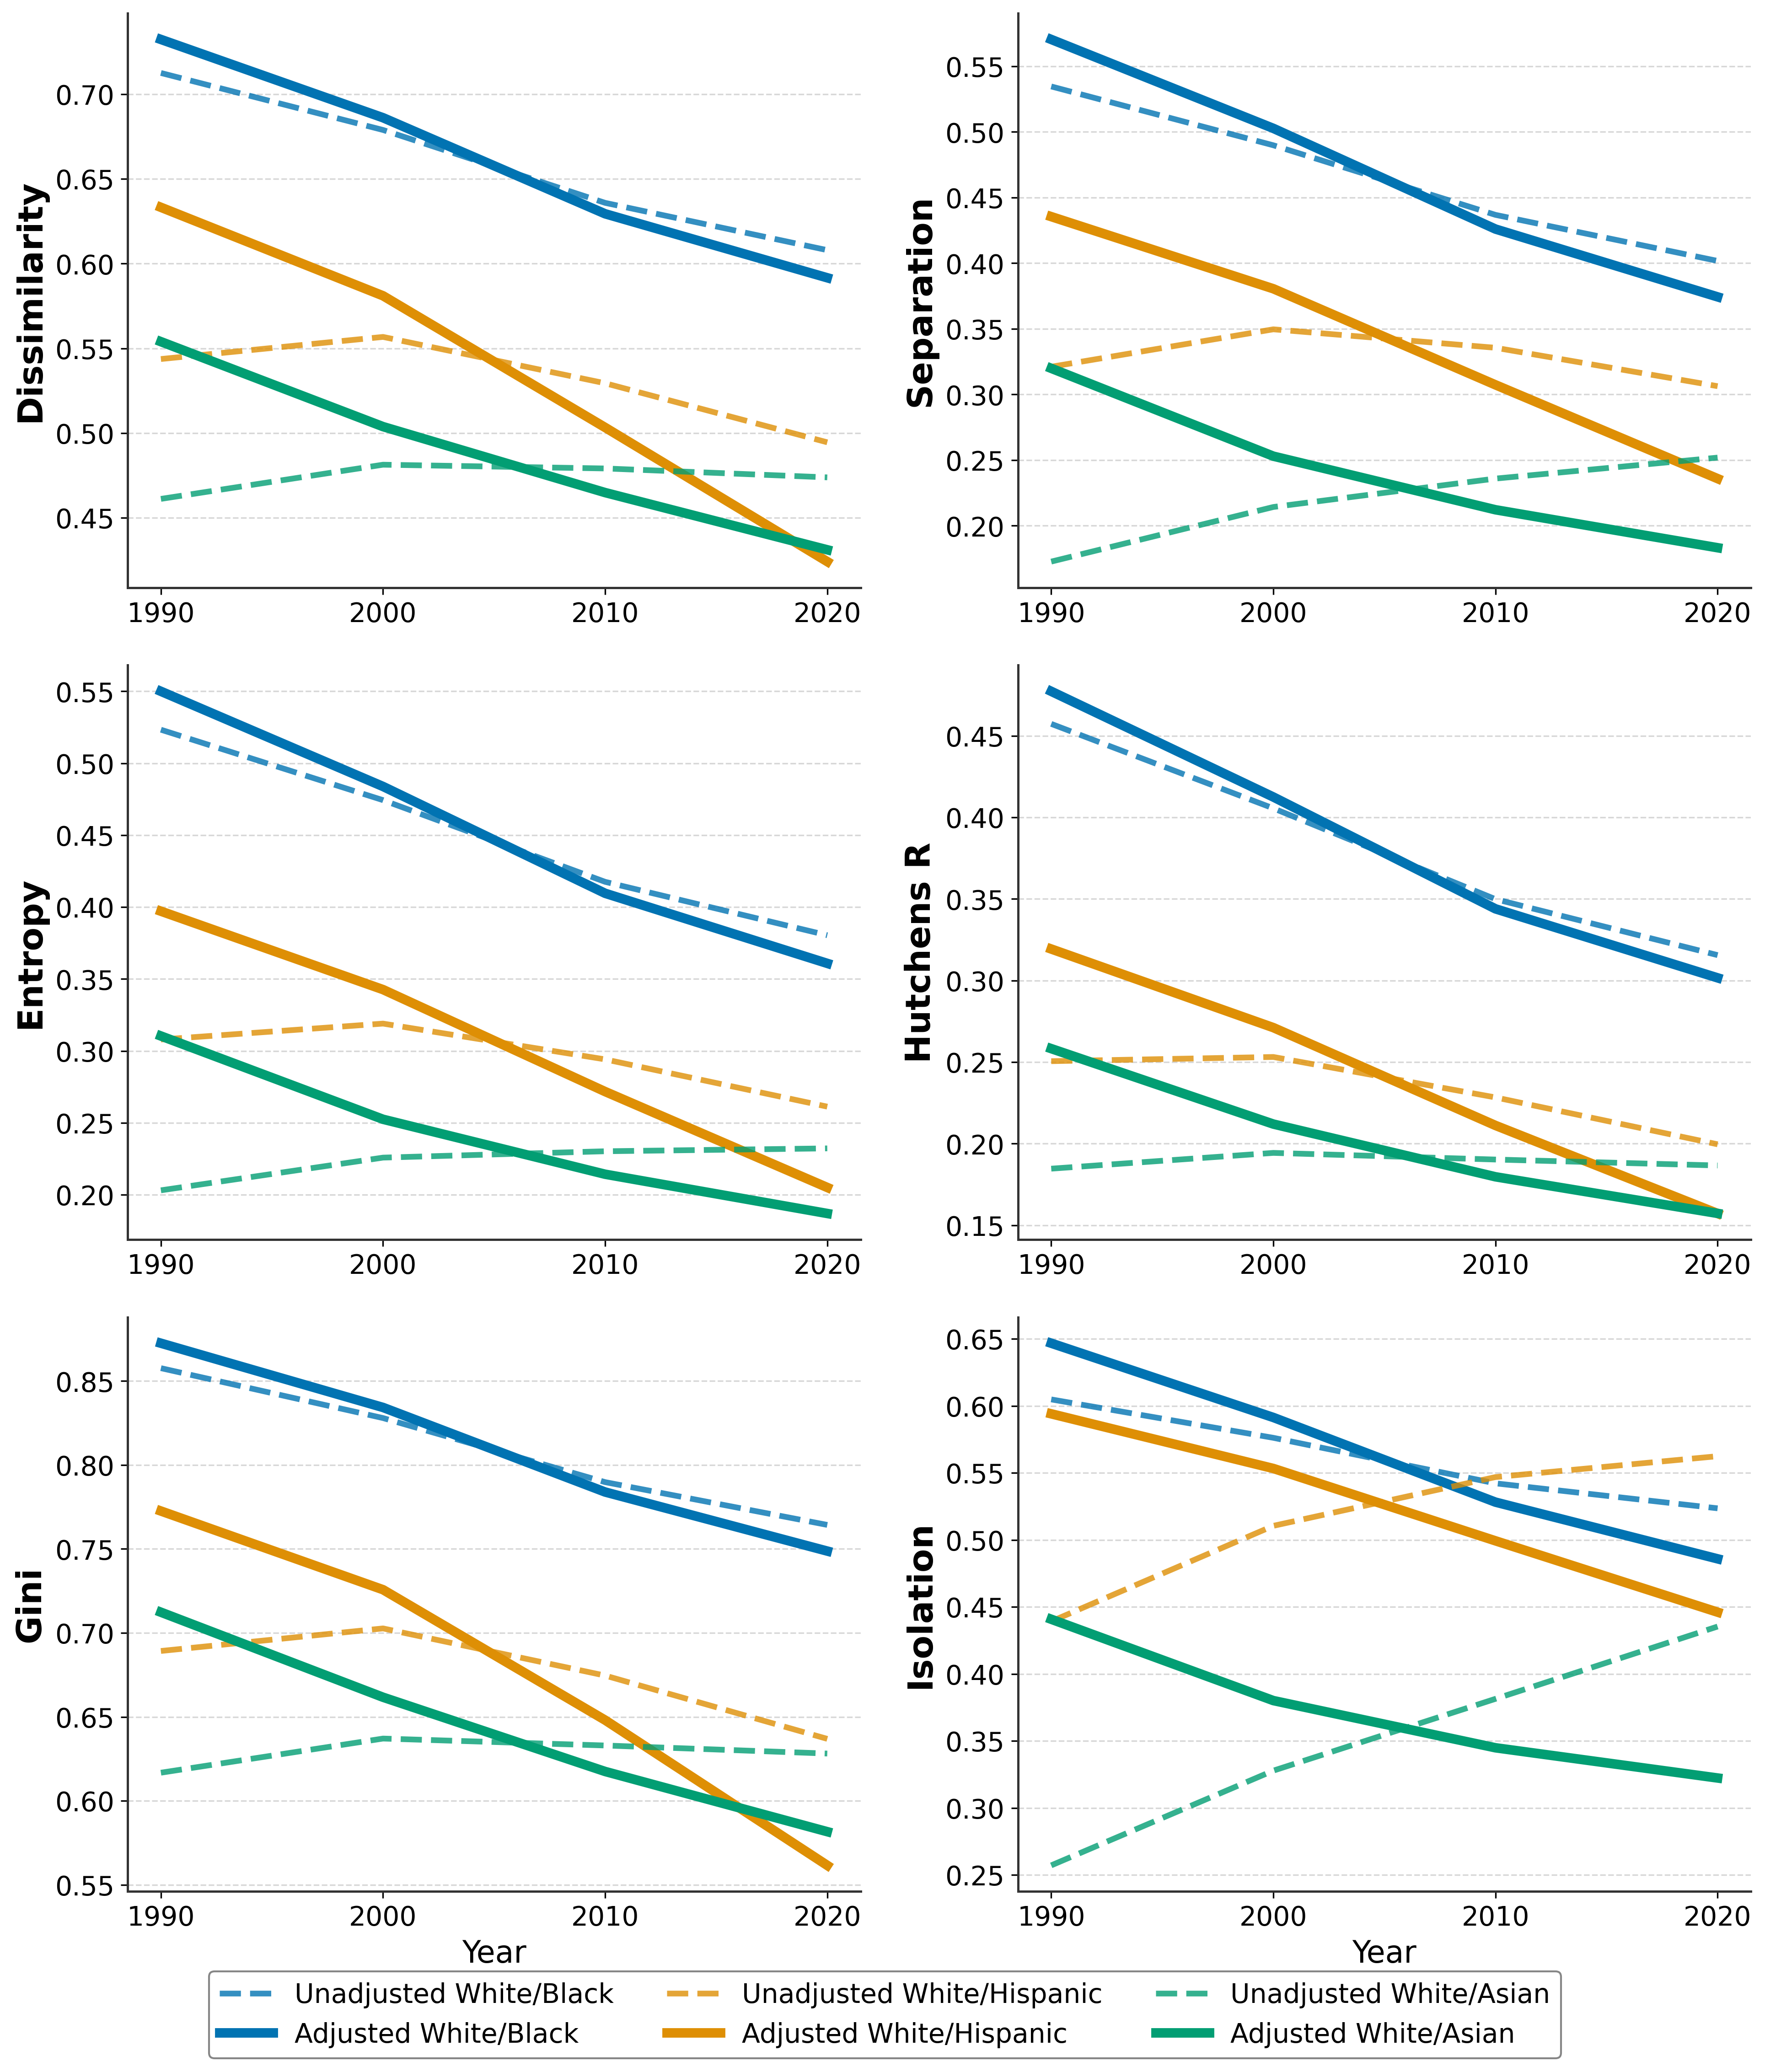

In [ ]:
# Import Avg from seg module
Avg = seg.Avg

# Define segregation indices to plot
seg_indices = ['D', 'S', 'Ent', 'R', 'G', 'Iso']
seg_index_titles = {
    'D': 'Dissimilarity',
    'S': 'Separation',
    'Ent': 'Entropy',
    'R': 'Hutchens R',
    'G': 'Gini',
    'Iso': 'Isolation'
}

# Parameters
group1 = 'white'
min_per = 3 #The minority group must constitute ≥3% of the two-group population in every decade
min_nei = 25 #  Only cities with ≥25 block group on each side of the target composition (the metro’s four-decade average) w
group2_list = ['black', 'hispanic', 'asian']

# Create figure with 3 rows, 2 columns
fig, axes = plt.subplots(3, 2, figsize=(13, 15))
axes = axes.flatten()

# Loop over each segregation index
for idx_num, seg_idx in enumerate(seg_indices):
    ax = axes[idx_num]
    
    # Get the unadjusted function from seg module
    Index_func = getattr(seg, seg_idx)
    
    # Create a wrapper for the adjusted version using a factory to avoid closure issues
    def make_index_info_func(idx_name):
        def Index_info_func(data, target_comp):
            return seg.Index(data, idx_name, target_comp)
        return Index_info_func
    
    Index_info_func = make_index_info_func(seg_idx)
    
    k = 0
    for group2 in group2_list:
        #Selects cities where the minority group was at least min_per every decade 
        t_allowed_cities = np.array(allowed_cities)[np.prod([(grouped2[group2].sum()/grouped2['total'].sum() >= min_per/100).loc[year].to_numpy() for year in decades],0).astype(bool)]
        his_avg_vec = np.array([np.mean([city_func(group1, group2, city, year2, Avg) for year2 in decades]) for city in t_allowed_cities])
        
        #Selects cities with ≥min_nei block group on each side of the target composition
        valid = np.array([np.prod([min_nei <= np.sum((grouped.get_group((t_allowed_cities[i], year2))[group1]/np.sum(grouped.get_group((t_allowed_cities[i], year2))[[group1, group2]],1)) 
        < his_avg_vec[i]) <= (len(grouped.get_group((t_allowed_cities[i], year2)))-min_nei) for year2 in decades]) for i in range(len(t_allowed_cities))]).astype(bool)
        
        t_allowed_cities = t_allowed_cities[valid]
        t_largest_cities = t_allowed_cities[np.flip(np.argsort([np.sum(grouped['total'].sum().loc[c]) for c in t_allowed_cities]))]
        
        t_pop_vec = [np.array([city_func(group1, group2, city, year, Tot) for city in t_largest_cities]) for year in decades]
        
        t_index_vec = [np.array([city_func(group1, group2, city, year, Index_func) for city in t_largest_cities]) for year in decades]
        t_hist_avg_vec = [np.mean([city_func(group1, group2, city, year, Avg) for year in decades]) for city in t_largest_cities]
        
        t_index_info_vec = [np.array([city_func(group1, group2, t_largest_cities[i], year, Index_info_func, t_hist_avg_vec[i]) for i in range(len(t_largest_cities))]) for year in decades]
        
        t_index_vec = [np.sum(t_index_vec[i]*t_pop_vec[i])/np.sum(t_pop_vec[i]) for i in range(len(t_index_vec))]
        t_index_info_vec = [np.sum(t_index_info_vec[i]*t_pop_vec[i])/np.sum(t_pop_vec[i]) for i in range(len(t_index_info_vec))]
        
        ax.plot(decades, t_index_vec, '--', color=colors[k], 
                label='Unadjusted {}/{}'.format(group1.capitalize(), group2.capitalize()), 
                linewidth=3, alpha=0.8)
        ax.plot(decades, t_index_info_vec, color=colors[k], 
                label='Adjusted {}/{}'.format(group1.capitalize(), group2.capitalize()), 
                linewidth=5)
        k += 1
    
    # Styling for each subplot
    ax.grid(axis='y', alpha=0.5, linestyle='--', linewidth=0.8)
    
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    for spine in ["left", "bottom"]:
        ax.spines[spine].set_color("#333333")
        ax.spines[spine].set_linewidth(1.2)
    
    ax.set_ylabel(seg_index_titles[seg_idx], fontsize=18, fontweight='bold')
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.set_xticks(decades)
    
    # Only bottom row gets x-label
    if idx_num >= 4:
        ax.set_xlabel('Year', fontsize=16)

# Create legend handles manually
legend_handles = []
for k, group2 in enumerate(group2_list):
    legend_handles.append(Line2D([0], [0], color=colors[k], linestyle='--', 
                                 linewidth=3, alpha=0.8,
                                 label='Unadjusted {}/{}'.format(group1.capitalize(), group2.capitalize())))
    legend_handles.append(Line2D([0], [0], color=colors[k], linestyle='-', 
                                 linewidth=5,
                                 label='Adjusted {}/{}'.format(group1.capitalize(), group2.capitalize())))

# Adjust layout
plt.tight_layout(rect=[0, 0.03, 1, 1], h_pad=2.0, w_pad=2.0)

# Add shared legend at the bottom
fig.legend(
    handles=legend_handles,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.01),
    ncol=3,
    fontsize=14,
    frameon=True,
    framealpha=0.95,
    edgecolor='gray',
    fancybox=True
)


# Save in both formats
# plt.savefig('segregation_indices_comparison.png', dpi=300, bbox_inches='tight', 
#            pad_inches=0.05, facecolor='white')

plt.show()

In [17]:
from collections import defaultdict
def sample_neighborhood_subsets(
    neighborhood_data,
    subset_size=100,
    max_per_bin=10000,
    n_bins=50,
    batch_size=50000,
    chunk_size=5000,
    max_iterations=100,
    min_edge_samples=100,
    composition_range=(0.4, 0.9),
    seed=12345,
    verbose=True
):
    rng = np.random.default_rng(seed)
    n_neighborhoods = neighborhood_data.shape[0]

    bin_edges = np.linspace(composition_range[0], composition_range[1], n_bins + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    binned_subsets = defaultdict(list)
    bin_counts = np.zeros(n_bins, dtype=int)

    for iteration in range(max_iterations):
        for _ in range(batch_size // chunk_size):
            rnd = rng.integers(0, n_neighborhoods, size=(chunk_size, subset_size))
            subset_data = neighborhood_data[rnd]

            subset_totals = subset_data.sum(axis=(1,2))
            subset_group1 = subset_data[...,0].sum(axis=1)

            with np.errstate(divide='ignore', invalid='ignore'):
                comps = np.divide(subset_group1, subset_totals,
                                  out=np.full_like(subset_group1, np.nan, dtype=float),
                                  where=subset_totals>0)

            valid = (comps >= bin_edges[0]) & (comps < bin_edges[-1]) & ~np.isnan(comps)
            rnd = rnd[valid]
            comps = comps[valid]

            bin_idx = np.digitize(comps, bin_edges) - 1

            for b in range(n_bins):
                if bin_counts[b] >= max_per_bin:
                    continue
                mask = bin_idx == b
                if not mask.any():
                    continue
                new = rnd[mask]
                space = max_per_bin - bin_counts[b]
                new = new[:space]
                binned_subsets[b].append(new)
                bin_counts[b] += len(new)

        if verbose and iteration % 10 == 0:
            print(f"Iter {iteration}: min={bin_counts.min()}, max={bin_counts.max()}")

        if np.all(bin_counts >= max_per_bin):
            break
        if bin_counts[0] >= min_edge_samples and bin_counts[-1] >= min_edge_samples and bin_counts.min() >= min_edge_samples:
            break

    result = {b: np.vstack(v) if len(v)>0 else np.empty((0, subset_size), int)
              for b,v in binned_subsets.items()}

    return result, bin_edges, bin_centers


def compute_subset_statistics(neighborhood_data, binned_subsets, func):
    """
    Compute a segregation statistic for all subsets in each bin.
    
    Parameters:
    -----------
    neighborhood_data : np.ndarray
        Shape (n_neighborhoods, 2)
    binned_subsets : dict
        Output from sample_neighborhood_subsets
    func : callable
        Function that takes subset data (n_subsets, subset_size, 2) and returns
        statistic values (n_subsets,)
    
    Returns:
    --------
    dict : {bin_index: np.ndarray of statistic values}
    """
    results = {}
    for bin_idx, subset_indices in binned_subsets.items():
        if len(subset_indices) == 0:
            results[bin_idx] = np.array([])
            continue
        
        # Get neighborhood data for these subsets
        subset_data = neighborhood_data[subset_indices]  # (n_subsets, subset_size, 2)
        results[bin_idx] = func(subset_data)
    
    return results

In [ ]:
largest_cities_name = ['New York', 'Los Angeles', 'Chicago']
largest_cities_full_name = np.array(allowed_cities)[np.flip(np.argsort(d.groupby('cbsatitle')['total'].sum().to_numpy()))]

grouped = d.groupby(['cbsatitle', 'year'])
decades = [1990, 2000, 2010, 2020]

In [19]:
#Create Subsets
group2 = 'black' #Can be changed to 'hispanic' or 'asian'

# number of neighborhoods per subset
subset_size = 100

all_binned_subsets = {}
all_bin_centers = {}
all_neighborhood_data = {}

for city in largest_cities_full_name[:3]:
    print(f"\n{'='*60}")
    print(f"Sampling for city: {city}")
    print('='*60)

    # Extract neighborhood data for this city (n,2)
    neighborhood_data = grouped.get_group((city, 2020))[['white', group2]].to_numpy()

    # Make sure there are zero-population neighborhoods
    totals = neighborhood_data.sum(axis=1)
    mask = totals > 0
    neighborhood_data = neighborhood_data[mask]

    all_neighborhood_data[city] = neighborhood_data

    # Compute city-wide composition to guide bin range if desired
    city_comp = neighborhood_data[:,0].sum() / neighborhood_data.sum()
    print(f"City-wide white share: {city_comp:.3f}")

    # Sample subsets
    binned_subsets, bin_edges, bin_centers = sample_neighborhood_subsets(
        neighborhood_data,
        subset_size=100,
        max_per_bin=10000, 
        n_bins=21,
        batch_size=50000,
        max_iterations=500,
        min_edge_samples=100,
        composition_range=(0.3, 0.95),  # wider for real cities
        verbose=True
    )

    all_binned_subsets[city] = binned_subsets
    all_bin_centers[city] = bin_centers

    # Print summary
    print(f"\nBin summary for {city}:")
    for bin_idx in range(len(bin_centers)):
        subsets = binned_subsets.get(bin_idx, np.empty((0, subset_size), dtype=int))
        if len(subsets) > 0:
            print(f"  Bin {bin_idx} ({bin_centers[bin_idx]:.3f}): n={len(subsets)}")



Sampling for city: New York-Newark-Jersey City, NY-NJ-PA
City-wide white share: 0.745
Iter 0: min=0, max=10000
Iter 10: min=0, max=10000
Iter 20: min=0, max=10000
Iter 30: min=0, max=10000
Iter 40: min=0, max=10000
Iter 50: min=0, max=10000
Iter 60: min=0, max=10000
Iter 70: min=0, max=10000
Iter 80: min=0, max=10000
Iter 90: min=0, max=10000
Iter 100: min=0, max=10000
Iter 110: min=0, max=10000
Iter 120: min=0, max=10000
Iter 130: min=0, max=10000
Iter 140: min=0, max=10000
Iter 150: min=0, max=10000
Iter 160: min=0, max=10000
Iter 170: min=0, max=10000
Iter 180: min=0, max=10000
Iter 190: min=0, max=10000
Iter 200: min=0, max=10000
Iter 210: min=0, max=10000
Iter 220: min=0, max=10000
Iter 230: min=0, max=10000
Iter 240: min=0, max=10000
Iter 250: min=0, max=10000
Iter 260: min=0, max=10000
Iter 270: min=0, max=10000
Iter 280: min=0, max=10000
Iter 290: min=0, max=10000
Iter 300: min=0, max=10000
Iter 310: min=0, max=10000
Iter 320: min=0, max=10000
Iter 330: min=0, max=10000
Iter 3

In [20]:
#Compute Segregration Indices
def compute_segregation_by_bin(neighborhood_data, binned_subsets, bin_centers, 
                                seg_funcs, target_composition=None, 
                                max_samples_per_bin=1000, min_samples=100):
    """
    Compute segregation indices for subsets in each bin.
    Bins with fewer than min_samples are excluded.
    """
    results = {name: {'compositions': [], 'means': [], 'stds': []} for name in seg_funcs}
    
    for bin_idx in sorted(binned_subsets.keys()):
        subset_indices = binned_subsets[bin_idx]
        
        # Skip bins with too few samples
        if len(subset_indices) < min_samples:
            continue
        
        # Limit samples for speed
        if len(subset_indices) > max_samples_per_bin:
            sample_idx = np.random.choice(len(subset_indices), max_samples_per_bin, replace=False)
            subset_indices = subset_indices[sample_idx]
        
        # Compute each segregation index
        for func_name, func in seg_funcs.items():
            values = []
            
            for indices in subset_indices:
                subset_data = neighborhood_data[indices]
                
                if target_composition is not None:
                    val = seg.Index(subset_data, func_name, target_composition)
                else:
                    val = func(subset_data)
                
                values.append(val)
            
            values = np.array(values)
            
            results[func_name]['compositions'].append(bin_centers[bin_idx])
            results[func_name]['means'].append(np.mean(values))
            results[func_name]['stds'].append(np.std(values))
    
    # Convert to arrays
    for func_name in results:
        for key in results[func_name]:
            results[func_name][key] = np.array(results[func_name][key])
    
    return results

# Segregation functions
seg_funcs = {
    'D': seg.D,
    'S': seg.S,
    'Ent': seg.Ent,
    'R': seg.R,
    'G': seg.G
}

all_results_unadjusted = {}
all_results_adjusted = {}

for city in largest_cities_full_name[:3]:
    print(f"\nComputing indices for {city}...")

    neighborhood_data = all_neighborhood_data[city]
    binned_subsets = all_binned_subsets[city]
    bin_centers = all_bin_centers[city]

    # City-wide composition
    city_composition = neighborhood_data[:, 0].sum() / neighborhood_data.sum()
    print(f"  City-wide white composition: {city_composition:.3f}")

    # Unadjusted segregation
    all_results_unadjusted[city] = compute_segregation_by_bin(
        neighborhood_data,
        binned_subsets,
        bin_centers,
        seg_funcs,
        target_composition=None,
        max_samples_per_bin=1000,
        min_samples=100
    )

    # Composition-adjusted segregation
    all_results_adjusted[city] = compute_segregation_by_bin(
        neighborhood_data,
        binned_subsets,
        bin_centers,
        seg_funcs,
        target_composition=city_composition,
        max_samples_per_bin=1000,
        min_samples=100
    )



Computing indices for New York-Newark-Jersey City, NY-NJ-PA...
  City-wide white composition: 0.745

Computing indices for Los Angeles-Long Beach-Anaheim, CA...
  City-wide white composition: 0.824

Computing indices for Chicago-Naperville-Elgin, IL-IN-WI...
  City-wide white composition: 0.758


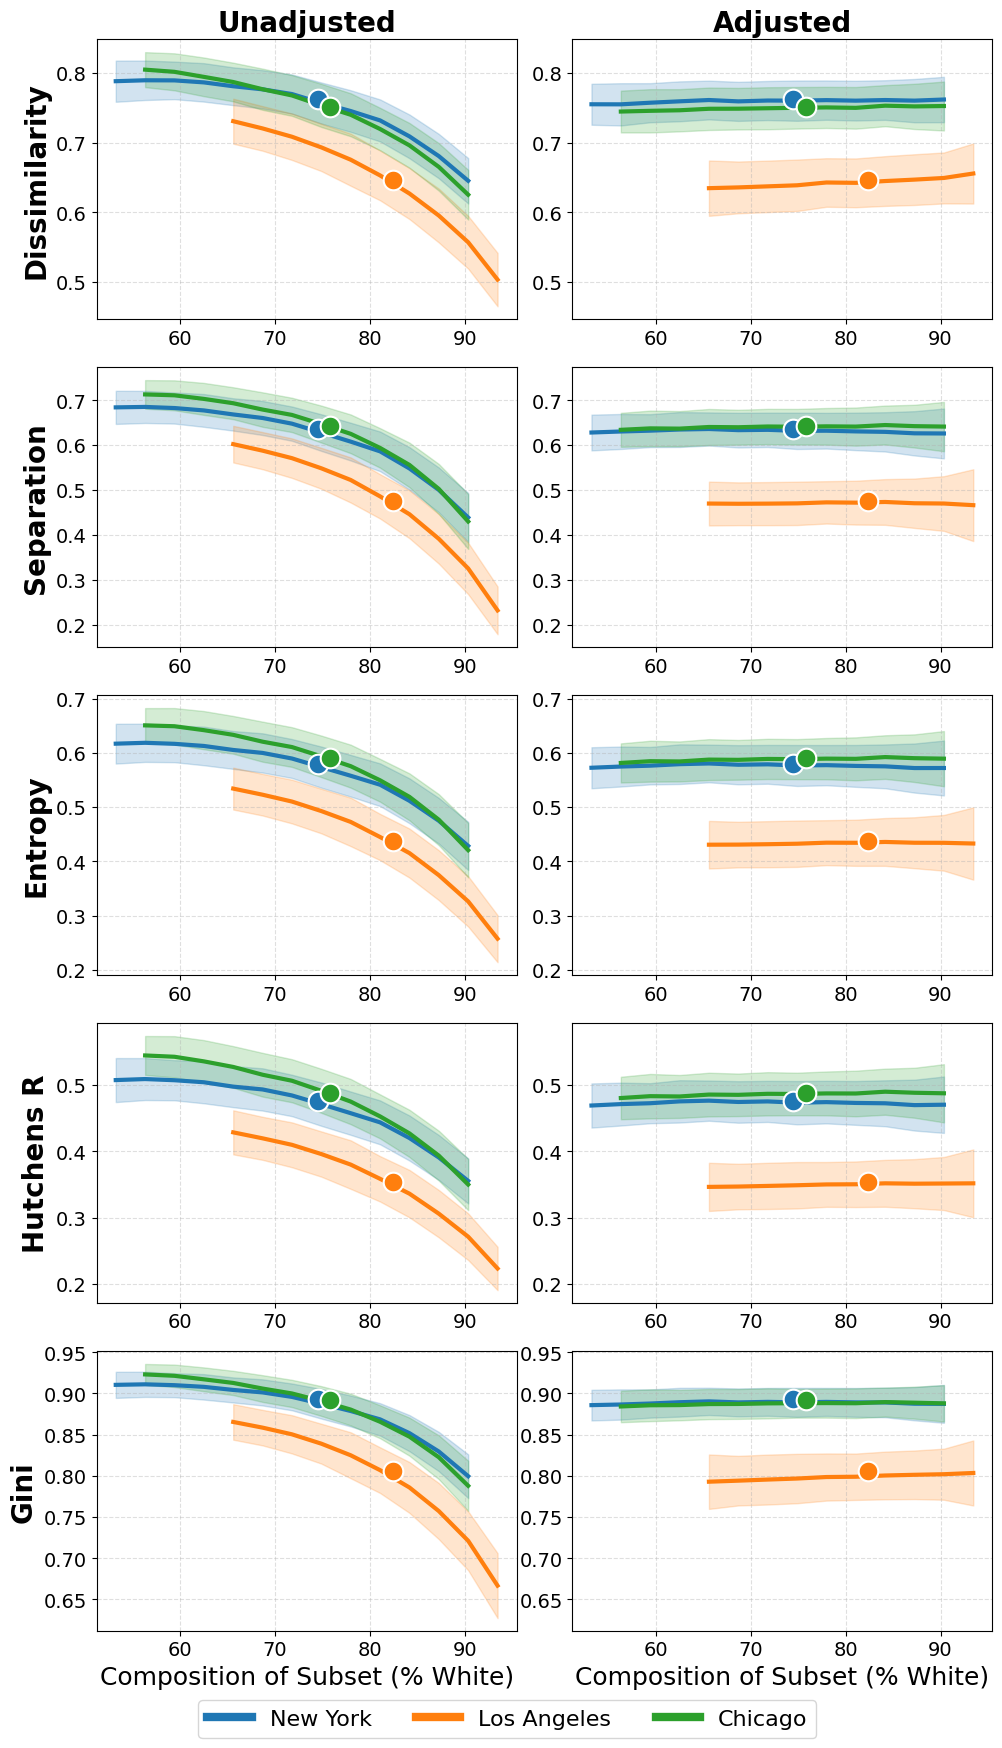

In [ ]:
plt.rcParams['figure.dpi'] = 100  # Increase DPI (default is usually 100)
# Short display names
cities = largest_cities_name[:3]

# Full names used as dictionary keys
cities_full = largest_cities_full_name[:3]

# Map short → full
city_full_map = dict(zip(cities, cities_full))

# Labels and colors (short names)
city_labels = {
    'New York': 'New York',
    'Los Angeles': 'Los Angeles',
    'Chicago': 'Chicago'
}

city_colors = {
    'New York': '#1f77b4',
    'Los Angeles': '#ff7f0e',
    'Chicago': '#2ca02c'
}

# Segregation indices
func_names = ['D', 'S', 'Ent', 'R', 'G']
func_titles = {
    'D': 'Dissimilarity',
    'S': 'Separation',
    'Ent': 'Entropy',
    'R': 'Hutchens R',
    'G': 'Gini'
}

# =============================================================================
# Figure setup
# =============================================================================

n_rows = len(func_names)
fig, axes = plt.subplots(n_rows, 2, figsize=(10, 18))
column_titles = ['Unadjusted', 'Adjusted']

# =============================================================================
# Plot
# =============================================================================

for row_idx, func_name in enumerate(func_names):

    # ================= LEFT COLUMN: UNADJUSTED =================
    ax_left = axes[row_idx, 0]
    x_min_all, x_max_all = np.inf, -np.inf

    for city in cities:
        city_full = city_full_map[city]

        neighborhood_data = all_neighborhood_data[city_full]
        data = all_results_unadjusted[city_full][func_name]

        if len(data['compositions']) == 0:
            continue

        x_vals = data['compositions'] * 100
        y_vals = data['means']
        y_std  = data['stds']

        x_min_all = min(x_min_all, np.min(x_vals))
        x_max_all = max(x_max_all, np.max(x_vals))

        color = city_colors[city]

        ax_left.plot(x_vals, y_vals, linewidth=3, color=color, label=city_labels[city])
        ax_left.fill_between(x_vals, y_vals - y_std, y_vals + y_std,
                             color=color, alpha=0.2)

        # Actual city segregation
        city_comp = neighborhood_data[:,0].sum() / neighborhood_data.sum()
        city_val = seg_funcs[func_name](neighborhood_data)

        ax_left.scatter(city_comp * 100, city_val, s=200, color=color,
                        edgecolor='white', linewidth=1.5, zorder=10)

    ax_left.grid(True, linestyle="--", alpha=0.4)
    ax_left.set_ylabel(func_titles[func_name], fontsize=20, fontweight='bold')

    if row_idx == n_rows - 1:
        ax_left.set_xlabel('Composition of Subset (% White)', fontsize=18)

    x_pad = (x_max_all - x_min_all) * 0.05
    ax_left.set_xlim(x_min_all - x_pad, x_max_all + x_pad)
    ax_left.tick_params(labelsize=14)

    if row_idx == 0:
        ax_left.set_title(column_titles[0], fontsize=20, fontweight='bold')

    # ================= RIGHT COLUMN: ADJUSTED =================
    ax_right = axes[row_idx, 1]
    x_min_all, x_max_all = np.inf, -np.inf

    for city in cities:
        city_full = city_full_map[city]

        neighborhood_data = all_neighborhood_data[city_full]
        data = all_results_adjusted[city_full][func_name]

        if len(data['compositions']) == 0:
            continue

        x_vals = data['compositions'] * 100
        y_vals = data['means']
        y_std  = data['stds']

        x_min_all = min(x_min_all, np.min(x_vals))
        x_max_all = max(x_max_all, np.max(x_vals))

        color = city_colors[city]

        ax_right.plot(x_vals, y_vals, linewidth=3, color=color)
        ax_right.fill_between(x_vals, y_vals - y_std, y_vals + y_std,
                              color=color, alpha=0.2)

        # Adjusted city segregation
        city_comp = neighborhood_data[:,0].sum() / neighborhood_data.sum()
        city_val = seg.Index(neighborhood_data, func_name, city_comp)

        ax_right.scatter(city_comp * 100, city_val, s=200, color=color,
                         edgecolor='white', linewidth=1.5, zorder=10)

    ax_right.grid(True, linestyle="--", alpha=0.4)

    if row_idx == n_rows - 1:
        ax_right.set_xlabel('Composition of Subset (% White)', fontsize=18)

    x_pad = (x_max_all - x_min_all) * 0.05
    ax_right.set_xlim(x_min_all - x_pad, x_max_all + x_pad)
    ax_right.tick_params(labelsize=14)

    if row_idx == 0:
        ax_right.set_title(column_titles[1], fontsize=20, fontweight='bold')

    # Match y-limits
    y_min = min(ax_left.get_ylim()[0], ax_right.get_ylim()[0])
    y_max = max(ax_left.get_ylim()[1], ax_right.get_ylim()[1])
    ax_left.set_ylim(y_min, y_max)
    ax_right.set_ylim(y_min, y_max)

# =============================================================================
# Legend
# =============================================================================

legend_handles = [
    Line2D([0], [0], color=city_colors[c], linewidth=6, label=city_labels[c])
    for c in cities
]

plt.tight_layout(rect=[0, 0.05, 1, 1])

fig.legend(
    handles=legend_handles,
    loc='lower center',
    bbox_to_anchor=(0.5, 0.025),
    ncol=len(cities),
    fontsize=16,
    frameon=True
)

plt.show()
